# Exploratory Data Analysis: Reddit discourse on AI companionship, AI sentience and "AI psychosis"

**Homework #3 · Computational Social Science** · Authors: Viktoriia Dyrda, Luka Doroshenko

**Time spent on this homework:** __ hours

**Contents:** 
1. Overview
2. Activity over time 
3. Author-level analysis 
4. Engagement
5. Submissions+comments merged analysis
6. Content analysis
7. Discussion intensity vs. real-world events

**Categories** (assigned during preprocessing): **general_ai** (r/singularity, r/ArtificialInteligence, r/artificial; baseline "AI as a tool"), **ai_partners** (r/MyBoyfriendIsAI, r/MyGirlfriendIsAI, r/aipartners, r/BeyondThePromptAI), **ai_sentience** (r/ArtificialSentience), **mental_health** (r/mentalhealth, r/therapy: only submissions that mention AI, plus their comments).


## 1. Overview

**Questions.** How big is the dataset, what does one row look like, what is the split between submissions and comments and between categories, and how complete is each field?

### 1.1 Load the dataset

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

DATA_PATH = "data/ai_psychosis.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
df.head()

,id,type,subreddit,category,author,created_utc,created_dt,month,score,upvote_ratio,...,is_gallery,is_crosspost,domain,url,link_flair_text,removed_by_category,distinguished,stickied,permalink,thread_mentions_ai
0,mpxmep2,comment,artificial,general_ai,FaceDeer,1746057609,2025-05-01 00:00:09,2025-05,-3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/artificial/comments/1kboupa/more_than_half_...,True
1,mpxmf5r,comment,ArtificialSentience,ai_sentience,Electrical_Hat_680,1746057614,2025-05-01 00:00:14,2025-05,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/ArtificialSentience/comments/1kaeeju/checku...,True
2,mpxmgx2,comment,ArtificialInteligence,general_ai,YellowSubreddit8,1746057630,2025-05-01 00:00:30,2025-05,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/ArtificialInteligence/comments/1kbmpv3/clau...,True
3,mpxmni2,comment,MyBoyfriendIsAI,ai_partners,SuddenFrosting951,1746057692,2025-05-01 00:01:32,2025-05,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/MyBoyfriendIsAI/comments/1kbtk85/how_to_sta...,True
4,mpxmso1,comment,singularity,general_ai,baklava-balaclava,1746057741,2025-05-01 00:02:21,2025-05,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/singularity/comments/1k8nfha/update_top_ope...,False


### 1.2 Setup: style, categories and derived fields

Derived fields used in the charts below: ts/hour/dow/month_dt (parsed from created_utc, UTC) and author_valid (author is present and is not a bot or a [deleted] account).

In [40]:
import matplotlib.axes, matplotlib.figure
if getattr(matplotlib.axes.Axes.set_title, "__name__", "") == "_set_title_w" or \
   getattr(matplotlib.figure.Figure.suptitle, "__name__", "") == "_suptitle_w":
    raise RuntimeError("Matplotlib is still patched by an older version of this notebook. Restart the kernel and run again from the top.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.labelsize": 11, "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False})

RNG_SEED = 42
SAMPLE_PER_CAT = 60_000 
CAT_ORDER = ["general_ai", "ai_partners", "ai_sentience", "mental_health"]
CAT_LABEL = {"general_ai": "General AI (baseline)", "ai_partners": "AI partners",
             "ai_sentience": "AI sentience", "mental_health": "Mental health"}
CAT_COL = {"general_ai": "#4C78A8", "ai_partners": "#E3447D", "ai_sentience": "#F2A33A", "mental_health": "#54A24B"}

def takeaway(*lines):
    display(Markdown("**Key numbers**\n\n" + "\n".join(f"- {l}" for l in lines)))

def thousands(ax, axis="y"):
    f = FuncFormatter(lambda v, p: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

def as_bool(s):
    return s.astype(str).str.lower().isin(["true", "1", "1.0"])

df["ts"] = pd.to_datetime(df["created_utc"], unit="s")
df["hour"] = df["ts"].dt.hour.astype("int8")
df["dow"] = df["ts"].dt.dayofweek.astype("int8")
df["month_dt"] = df["ts"].dt.to_period("M").dt.to_timestamp()
for c in ["score", "upvote_ratio", "num_comments", "subreddit_subscribers"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

BOT_AUTHORS = {"AutoModerator", "[deleted]", "BotDefense", "RemindMeBot", "sneakpeekbot", "WikiSummarizerBot"}
df["author_valid"] = df["author"].notna() & ~df["author"].isin(BOT_AUTHORS)

for c in ["type", "subreddit", "category"]:
    df[c] = df[c].astype("category")
df["category"] = df["category"].cat.reorder_categories([c for c in CAT_ORDER if c in df["category"].cat.categories])
CATS = list(df["category"].cat.categories)
cat_of = df.groupby("subreddit", observed=True)["category"].first()

va = df.loc[df["author_valid"], ["author", "category", "subreddit", "month_dt", "ts"]]

def get_text(frame):
    body = frame["text"].fillna("").astype(str)
    body = body.where(~body.str.strip().isin(["[removed]", "[deleted]", "nan"]), "")
    ttl = frame["title"].fillna("").astype(str) if "title" in frame.columns else pd.Series("", index=frame.index)
    out = np.where((frame["type"] == "submission").values, (ttl + ". " + body).values, body.values)
    return pd.Series(out, index=frame.index).str.strip(" .")


rng = np.random.default_rng(RNG_SEED)
idx = []
for c in df["category"].cat.categories:
    pos = np.flatnonzero((df["category"] == c).values)
    idx.append(rng.choice(pos, size=min(SAMPLE_PER_CAT, len(pos)), replace=False))
S = df.iloc[np.sort(np.concatenate(idx))].copy()
S["text"] = get_text(S)
S = S[S["text"].str.len() > 0].copy()
S["text_l"] = S["text"].str.lower()
S["n_words"] = S["text"].str.split().str.len()   
S["n_chars"] = S["text"].str.len()

print("setup done:", f"{len(df):,} rows,", f"{len(va):,} rows with a valid author")

setup done: 2,409,486 rows, 2,407,139 rows with a valid author


### 1.3 General information

Size on disk and in memory, time span, number of distinct authors and subreddits, and the split of rows by type.

In [3]:
size_mb = os.path.getsize(DATA_PATH) / 1024 ** 2
n_type = df["type"].value_counts()
info = pd.Series({
    "file size on disk (MB)": round(size_mb, 1),
    "rows": f"{len(df):,}",
    "columns (raw)": df.shape[1] - 5,
    "memory in this session (GB)": round(df.memory_usage(deep=True).sum() / 1024 ** 3, 2),
    "first record (UTC)": str(df["ts"].min()),
    "last record (UTC)": str(df["ts"].max()),
    "months covered": df["month"].nunique(),
    "subreddits": df["subreddit"].nunique(),
    "categories": df["category"].nunique(),
    "comments": f"{n_type.get('comment', 0):,}",
    "submissions": f"{n_type.get('submission', 0):,}",
    "comments per submission": round(n_type.get("comment", 0) / max(n_type.get("submission", 1), 1), 1),
    "distinct valid authors": f"{df.loc[df.author_valid, 'author'].nunique():,}",
    "rows without usable author": f"{(~df.author_valid).mean():.1%}",
    "distinct threads": f"{df['thread_id'].nunique():,}",
}, name="value")
display(info.to_frame())

display(pd.crosstab(df["subreddit"], df["type"], margins=True).join(
    df.groupby("subreddit", observed=True)["category"].first().rename("category")).sort_values("All", ascending=False))

,value
file size on disk (MB),1238.0
rows,"2,409,486"
columns (raw),34
memory in this session (GB),3.37
first record (UTC),2025-05-01 00:00:09
last record (UTC),2026-08-31 23:59:42
months covered,16
subreddits,10
categories,4
comments,"2,251,711"


,comment,submission,All,category
subreddit,,,,
All,2251711,157775,2409486,NaN
singularity,1089197,28352,1117549,general_ai
ArtificialInteligence,590999,73491,664490,general_ai
artificial,226518,28670,255188,general_ai
ArtificialSentience,160177,10740,170917,ai_sentience
MyBoyfriendIsAI,95093,6775,101868,ai_partners
BeyondThePromptAI,27658,2982,30640,general_ai
aipartners,22221,2706,24927,ai_partners
therapy,16155,1320,17475,mental_health


### 1.4 Chart 1: rows by type and by category

**Reading the chart.** Left: how much of the data are comments versus submissions. Right: how the rows split across the four categories. The categories are very unbalanced (general_ai holds most rows), so later charts compare **shares and rates** instead of raw counts whenever categories are compared.

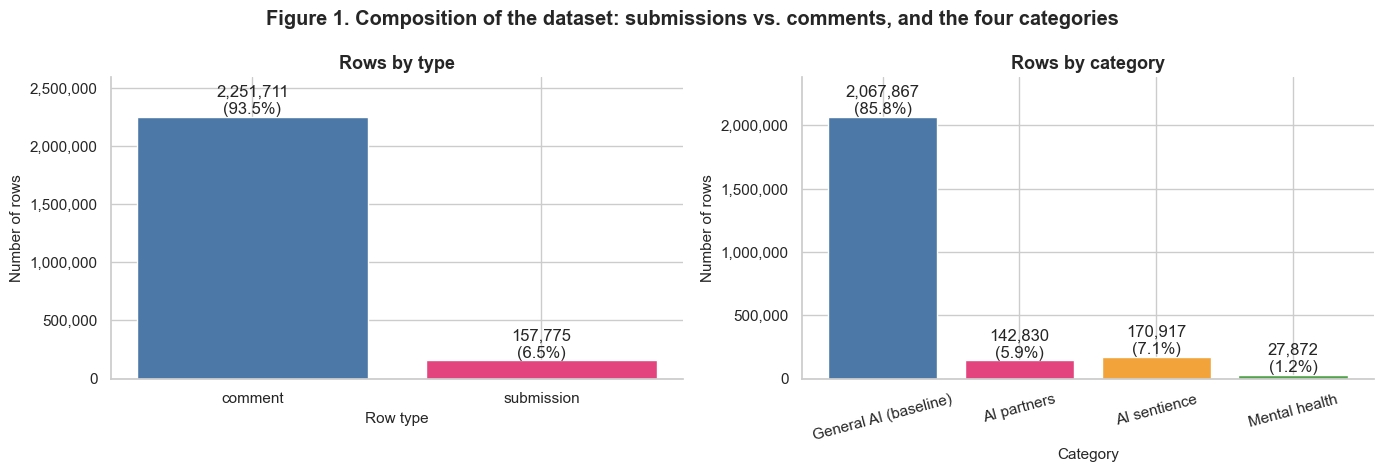

In [4]:
type_counts = df["type"].value_counts()
cat_counts = df["category"].value_counts().reindex(CATS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
b = axes[0].bar(type_counts.index.astype(str), type_counts.values, color=["#4C78A8", "#E3447D"][:len(type_counts)])
axes[0].bar_label(b, labels=[f"{v:,}\n({v/len(df):.1%})" for v in type_counts.values])
axes[0].set_ylabel("Number of rows"); axes[0].set_xlabel("Row type"); thousands(axes[0]); axes[0].margins(y=0.15)
axes[0].set_title("Rows by type")

b = axes[1].bar([CAT_LABEL[c] for c in cat_counts.index], cat_counts.values, color=[CAT_COL[c] for c in cat_counts.index])
axes[1].bar_label(b, labels=[f"{v:,}\n({v/len(df):.1%})" for v in cat_counts.values])
axes[1].set_ylabel("Number of rows"); axes[1].set_xlabel("Category"); thousands(axes[1]); axes[1].margins(y=0.15)
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_title("Rows by category")
fig.suptitle("Figure 1. Composition of the dataset: submissions vs. comments, and the four categories", fontweight="bold")
plt.tight_layout(); plt.show()

### 1.5 Chart 2: missing values

**Question.** Which fields are empty, and is that structural (a field that only exists for submissions) or a real data gap? Fields that are ~100 % missing for one row type but filled for the other (upvote_ratio, num_comments, domain, subreddit_subscribers, ...) are *submission-only attributes*. Columns missing for both types (e.g. author) are genuine gaps such as deleted accounts.

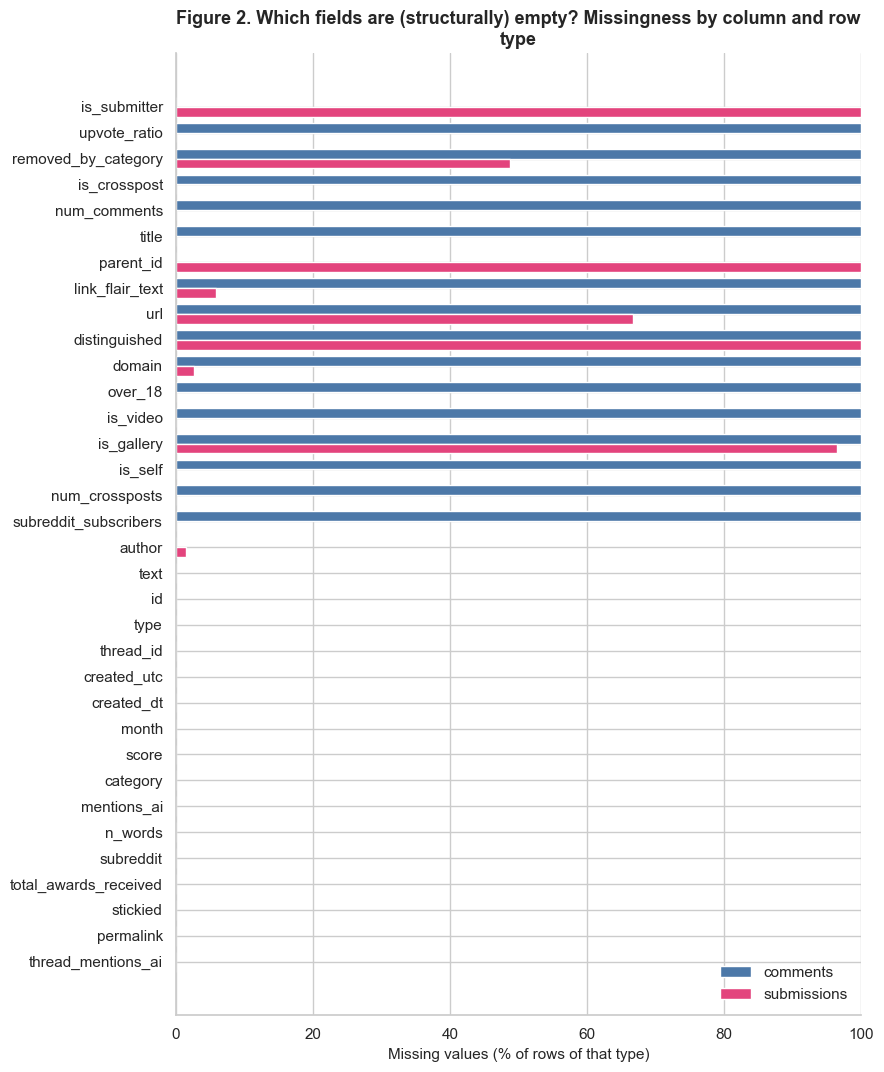

In [5]:
# Figure 2: share of missing values per column, split by row type
miss = (df.drop(columns=["ts", "hour", "dow", "month_dt", "author_valid"], errors="ignore")
          .isna().groupby(df["type"], observed=True).mean().T * 100)
miss = miss.loc[miss.max(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(miss))))
y = np.arange(len(miss)); h = 0.38
ax.barh(y - h/2, miss["comment"], h, color="#4C78A8", label="comments")
ax.barh(y + h/2, miss["submission"], h, color="#E3447D", label="submissions")
ax.set_yticks(y); ax.set_yticklabels(miss.index); ax.invert_yaxis()
ax.set_xlabel("Missing values (% of rows of that type)"); ax.set_xlim(0, 100)
ax.set_title("Figure 2. Which fields are (structurally) empty? Missingness by column and row\ntype")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 1.6 Chart 3: size of every community (records, threads, authors)

Log scale, because r/singularity is hundreds of times larger than r/mentalhealth. The table printed below the chart adds *records per author*, a first indicator of how conversational a community is.

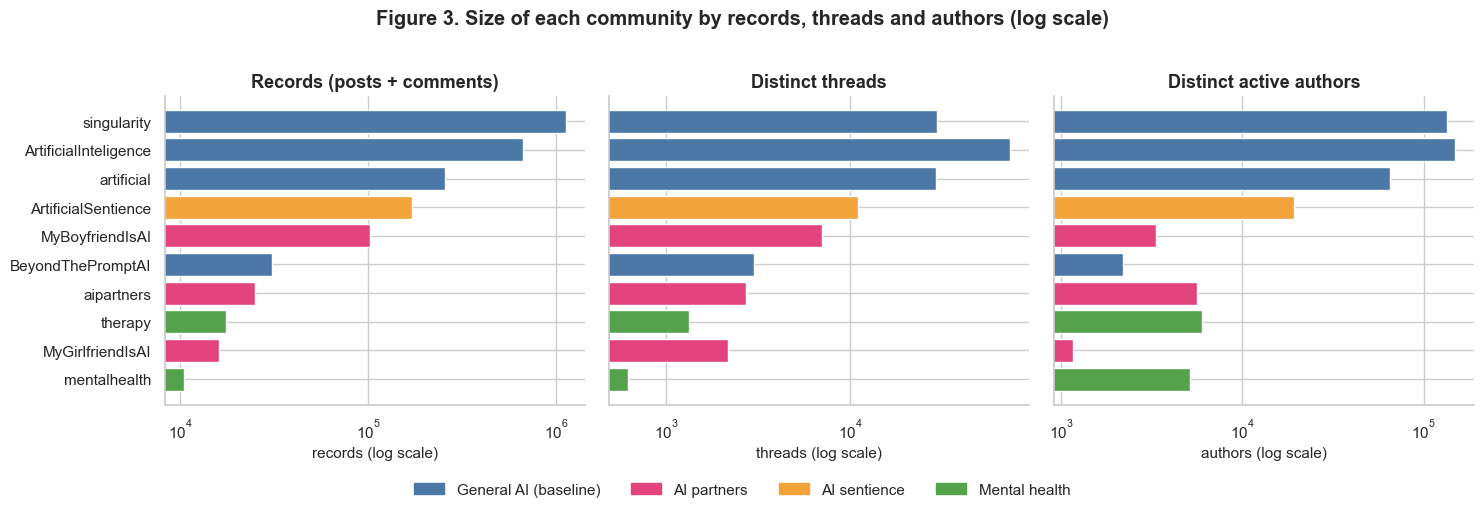

,records,threads,authors,category,records_per_author
subreddit,,,,,
singularity,1117549,29720,134770,general_ai,8.3
ArtificialInteligence,664490,74010,148467,general_ai,4.5
artificial,255188,29237,65394,general_ai,3.9
ArtificialSentience,170917,11078,19254,ai_sentience,8.9
MyBoyfriendIsAI,101868,7031,3341,ai_partners,30.5
BeyondThePromptAI,30640,3002,2197,general_ai,13.9
aipartners,24927,2729,5653,ai_partners,4.4
therapy,17475,1330,5957,mental_health,2.9
MyGirlfriendIsAI,16035,2180,1166,ai_partners,13.8


In [6]:
# Figure 3: dataset "fingerprint": records, authors, threads per subreddit
g = df.groupby("subreddit", observed=True)
fp = pd.DataFrame({
    "records": g.size(),
    "threads": g["thread_id"].nunique(),
    "authors": df[df.author_valid].groupby("subreddit", observed=True)["author"].nunique(),
    "category": g["category"].first(),
}).sort_values("records", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, col, ttl in zip(axes, ["records", "threads", "authors"],
                        ["Records (posts + comments)", "Distinct threads", "Distinct active authors"]):
    ax.barh(fp.index.astype(str), fp[col], color=[CAT_COL[c] for c in fp["category"]])
    ax.set_xscale("log"); ax.set_title(ttl); ax.set_xlabel(f"{col} (log scale)")
handles = [plt.Rectangle((0, 0), 1, 1, color=CAT_COL[c]) for c in CAT_ORDER]
fig.legend(handles, [CAT_LABEL[c] for c in CAT_ORDER], ncol=4, loc="upper center", bbox_to_anchor=(0.5, 0.02))
fig.suptitle("Figure 3. Size of each community by records, threads and authors (log scale)", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()
fp["records_per_author"] = fp["records"] / fp["authors"]
display(fp.sort_values("records", ascending=False).round(1))

## 2. Activity over time

**Questions.** How did the monthly volume of each subreddit and each category evolve between May 2025 and Aug 2026? When during the week and day are people active?

### 2.1 Chart 4: monthly volume per subreddit

Each panel has its **own y-axis**: the aim is the *shape* (growth, decay, sudden shifts) of each community, not its size. With one shared axis everything except r/singularity would look flat.

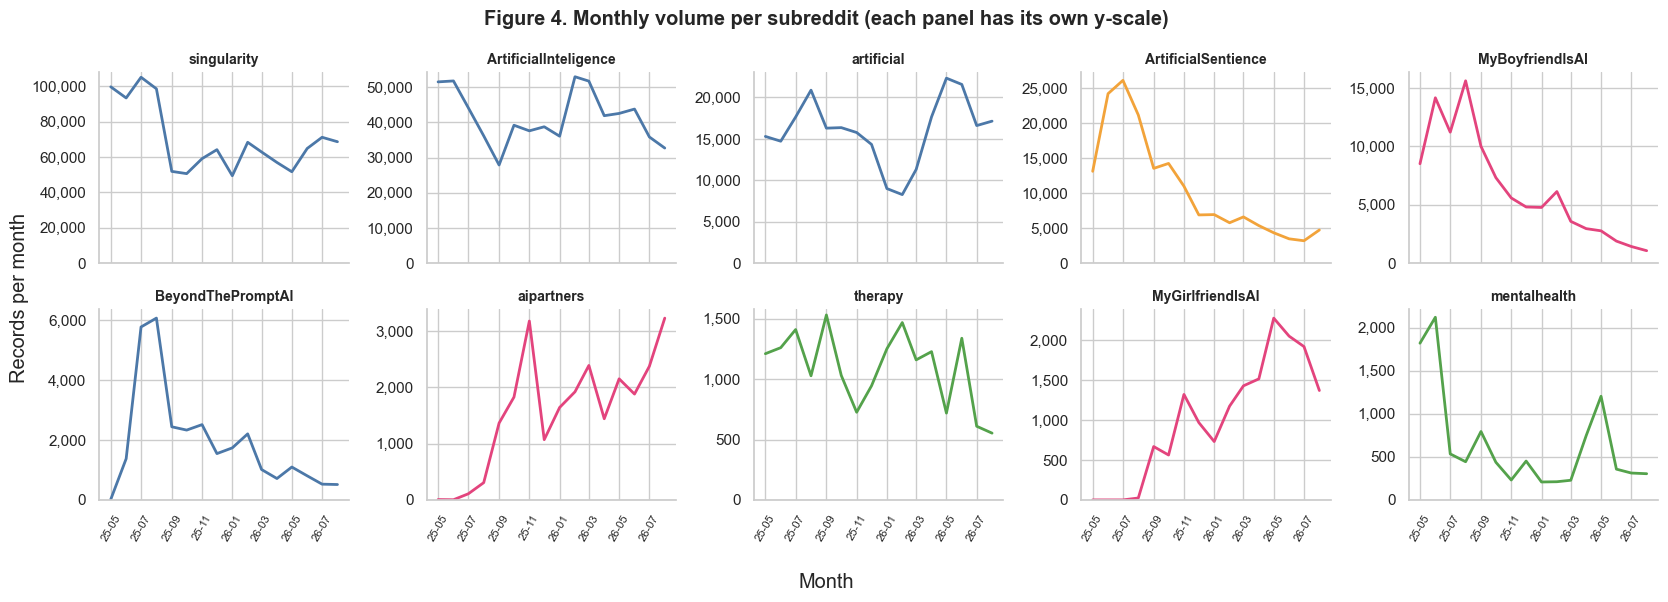

In [7]:
# Figure 4: one panel per subreddit, free y-axis (small multiples)
ms = df.groupby(["month_dt", "subreddit"], observed=True).size().unstack(fill_value=0)
order = df["subreddit"].value_counts().index.tolist()
fig, axes = plt.subplots(2, 5, figsize=(17, 6), sharex=True)
cat_of = df.groupby("subreddit", observed=True)["category"].first()
for ax, s in zip(axes.ravel(), order):
    ax.plot(ms.index, ms[s], color=CAT_COL[cat_of[s]], lw=2)
    ax.set_title(s, fontsize=10); thousands(ax)
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m"))
    ax.set_ylim(bottom=0)
fig.supxlabel("Month"); fig.supylabel("Records per month")
fig.suptitle("Figure 4. Monthly volume per subreddit (each panel has its own y-scale)", fontweight="bold")
plt.tight_layout(); plt.show()

### 2.2 Chart 5: monthly volume by category (stacked)

Total height = all records in that month; colours = categories. Use this chart for the overall trend, and Figure 4 to see which subreddit drives it.

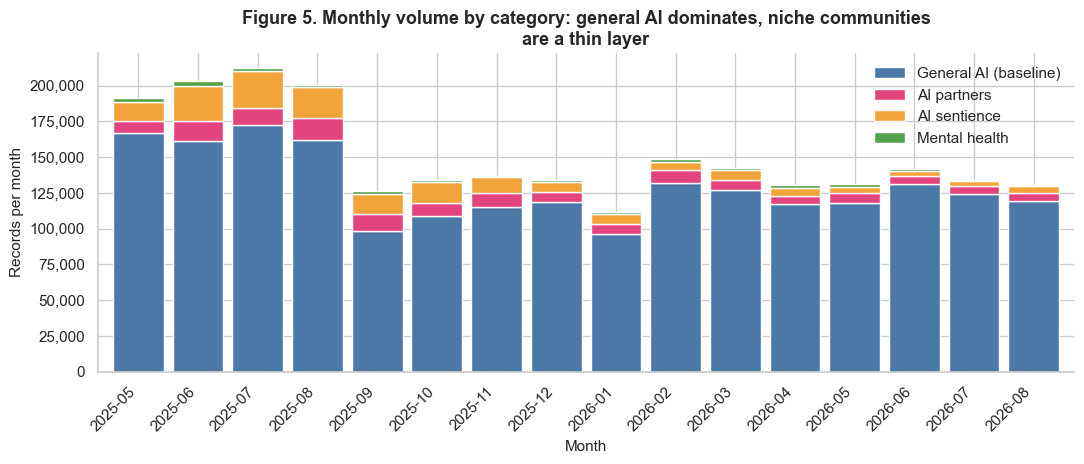

In [8]:
# Figure 5: monthly volume stacked by category (full data)
m = df.groupby(["month_dt", "category"], observed=True).size().unstack(fill_value=0)[[c for c in CAT_ORDER if c in df.category.cat.categories]]
fig, ax = plt.subplots(figsize=(11, 4.8))
m_bar = m.copy(); m_bar.index = [d.strftime("%Y-%m") for d in m.index]
m_bar.plot.bar(stacked=True, ax=ax, color=[CAT_COL[c] for c in m.columns], width=0.85)
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.set_xlabel("Month"); ax.set_ylabel("Records per month"); thousands(ax)
ax.set_title("Figure 5. Monthly volume by category: general AI dominates, niche communities\nare a thin layer")
ax.legend([CAT_LABEL[c] for c in m.columns], loc="upper right")
plt.tight_layout(); plt.show()

### 2.3 Chart 6: weekly rhythm (weekday × hour)

**Question.** When is each community awake? Cells show the share of a category's records posted in each weekday-hour slot (UTC). Reddit gives no user time zone and the audience is geographically mixed, so this is suggestive rather than conclusive.

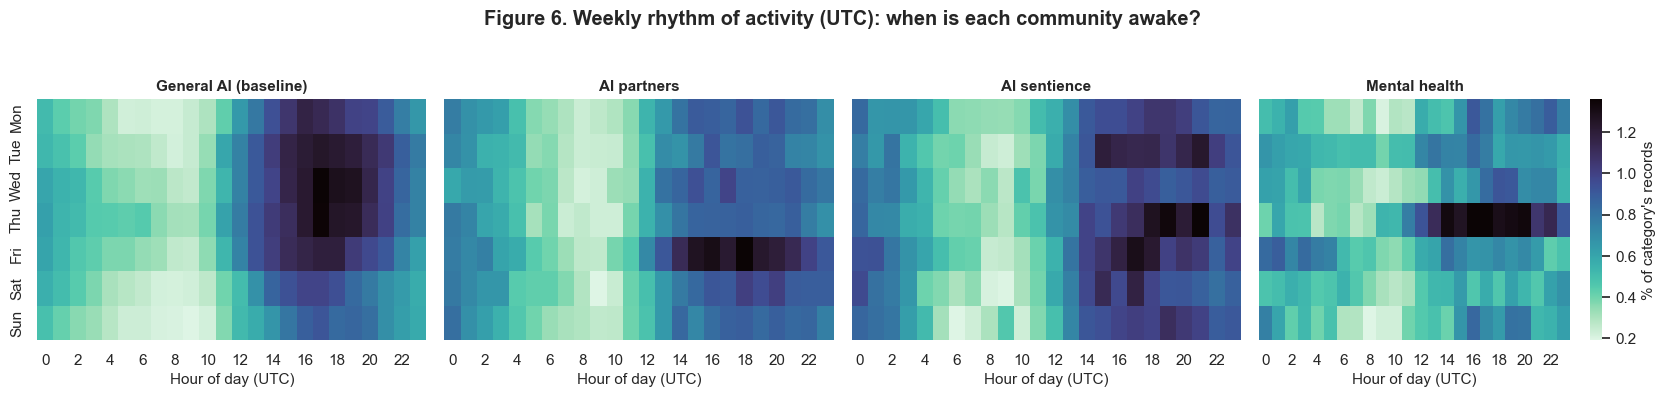

In [9]:
# Figure 6: when do people post? weekday x hour heatmap (UTC), overall and by category
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for ax, c in zip(axes, [c for c in CAT_ORDER if c in df.category.cat.categories]):
    h = df[df.category == c].groupby(["dow", "hour"]).size().unstack(fill_value=0)
    h = h.div(h.values.sum()) * 100
    sns.heatmap(h, cmap="mako_r", ax=ax, cbar=ax is axes[-1], cbar_kws={"label": "% of category's records"},
                yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    ax.set_title(CAT_LABEL[c], fontsize=11); ax.set_xlabel("Hour of day (UTC)"); ax.set_ylabel("")
fig.suptitle("Figure 6. Weekly rhythm of activity (UTC): when is each community awake?", fontweight="bold", y=1.04)
plt.tight_layout(); plt.show()

In [10]:
we = df.assign(weekend=df.dow >= 5).groupby("category", observed=True)["weekend"].mean() * 100
takeaway("Share of activity on weekends (28.6% would be uniform): " + ", ".join(f"{CAT_LABEL[c]} {v:.1f}%" for c, v in we.items()))

**Key numbers**

- Share of activity on weekends (28.6% would be uniform): General AI (baseline) 25.9%, AI partners 28.2%, AI sentience 27.8%, Mental health 24.1%

## 3. Author-level analysis

**Questions.** Do the same people take part in different communities? Is participation concentrated among a few heavy users? Do communities keep attracting new authors? Bots, [deleted] accounts and rows without author are excluded (author_valid).

### 3.1 Chart 7: author overlap between categories

Each cell shows the **% of the row category's authors who are also active in the column category**. The diagonal is 100 % by definition. Low off-diagonal values mean the categories are separate "worlds"; high values mean the same people move between them. The matrix is *not* symmetric because categories differ in size.

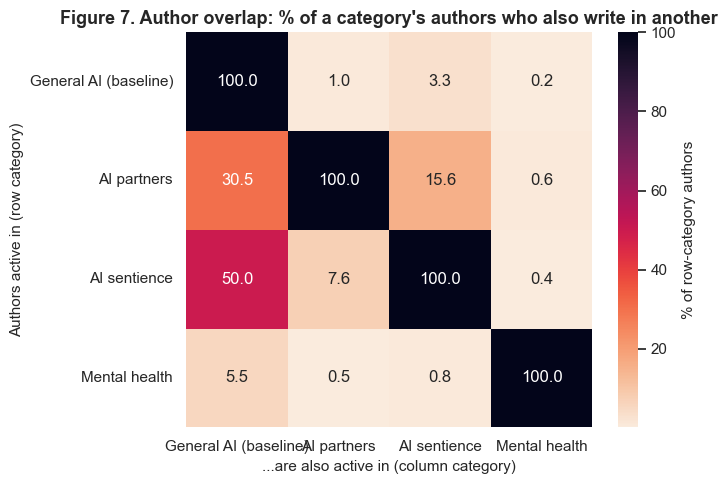

**Key numbers**

- 3.9% of all authors are active in 2+ categories; 1,150 authors in 3+ categories

In [11]:
# Figure 7: author overlap between categories: do the same people appear in different worlds?
sets = {c: set(va.loc[va.category == c, "author"].unique()) for c in CAT_ORDER if c in df.category.cat.categories}
cats = list(sets)
M = pd.DataFrame([[len(sets[a] & sets[b]) / len(sets[a]) * 100 for b in cats] for a in cats],
                 index=[CAT_LABEL[c] for c in cats], columns=[CAT_LABEL[c] for c in cats])
fig, ax = plt.subplots(figsize=(7.2, 5))
sns.heatmap(M, annot=True, fmt=".1f", cmap="rocket_r", ax=ax, cbar_kws={"label": "% of row-category authors"})
ax.set_xlabel("...are also active in (column category)"); ax.set_ylabel("Authors active in (row category)")
ax.set_title("Figure 7. Author overlap: % of a category's authors who also write in another")
plt.tight_layout(); plt.show()

multi = va.groupby("author", observed=True)["category"].nunique()
takeaway(f"{(multi >= 2).mean()*100:.1f}% of all authors are active in 2+ categories; {(multi >= 3).sum():,} authors in 3+ categories")

### 3.2 Chart 8: how concentrated is participation?

Left: for each x, the share of authors who wrote at least x records (log-log). A long straight tail means a few authors write enormous amounts. Right: the Lorenz curve; the further it bends from the diagonal, the higher the Gini coefficient (0 = everyone writes equally, 1 = one author writes everything).

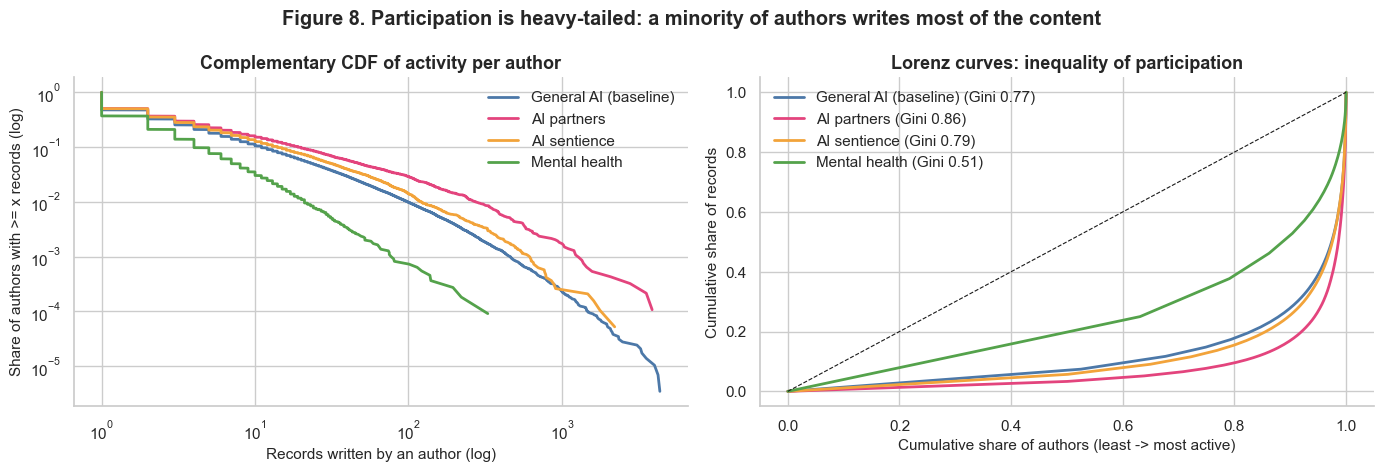

**Key numbers**

- Share of records produced by the most active 1% of authors: General AI (baseline) 36%, AI partners 44%, AI sentience 35%, Mental health 18%

In [12]:
# Figure 8: activity per author: how skewed is participation? (CCDF, log-log)
va = df[df.author_valid]
apc = va.groupby(["category", "author"], observed=True).size().rename("n").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for c in [c for c in CAT_ORDER if c in df.category.cat.categories]:
    n = np.sort(apc.loc[apc.category == c, "n"].values)
    ccdf = 1 - np.arange(len(n)) / len(n)
    axes[0].plot(n, ccdf, color=CAT_COL[c], lw=2, label=CAT_LABEL[c])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Records written by an author (log)"); axes[0].set_ylabel("Share of authors with >= x records (log)")
axes[0].set_title("Complementary CDF of activity per author"); axes[0].legend()

_trapz = getattr(np, 'trapezoid', None) or np.trapz
def lorenz(v):
    v = np.sort(v); cum = np.cumsum(v) / v.sum()
    return np.insert(np.arange(1, len(v) + 1) / len(v), 0, 0), np.insert(cum, 0, 0)
gini = {}
for c in [c for c in CAT_ORDER if c in df.category.cat.categories]:
    x, y = lorenz(apc.loc[apc.category == c, "n"].values.astype(float))
    gini[c] = 1 - 2 * _trapz(y, x)
    axes[1].plot(x, y, color=CAT_COL[c], lw=2, label=f"{CAT_LABEL[c]} (Gini {gini[c]:.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_xlabel("Cumulative share of authors (least -> most active)"); axes[1].set_ylabel("Cumulative share of records")
axes[1].set_title("Lorenz curves: inequality of participation"); axes[1].legend(loc="upper left")
fig.suptitle("Figure 8. Participation is heavy-tailed: a minority of authors writes most of the content", fontweight="bold")
plt.tight_layout(); plt.show()
top1 = {c: apc[apc.category == c].nlargest(max(1, int(0.01 * (apc.category == c).sum())), "n")["n"].sum() / apc[apc.category == c]["n"].sum() for c in gini}
takeaway("Share of records produced by the most active 1% of authors: " + ", ".join(f"{CAT_LABEL[c]} {v*100:.0f}%" for c, v in top1.items()))

### 3.3 Chart 9: new vs. returning authors per month

Bars count distinct active authors per month; the coloured part are authors seen for the **first time** that month. **Caveat:** the first month of the dataset is left-censored, since everybody looks "new" in May 2025, so ignore that bar when judging growth.

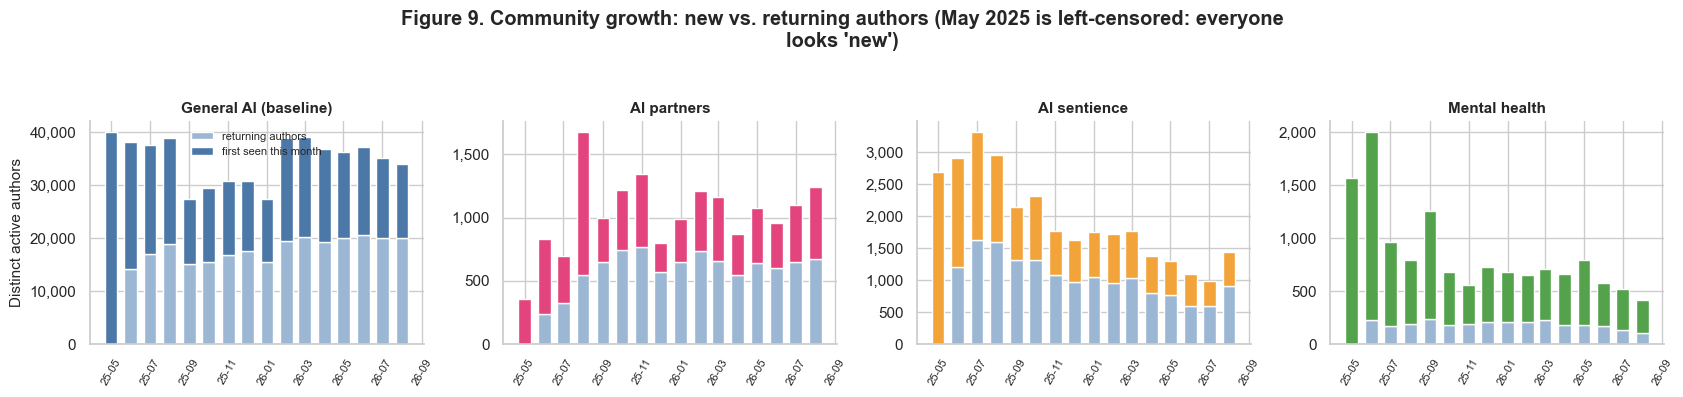

In [13]:
# Figure 9: new vs. returning authors per month, per category
first_seen = va.groupby("author")["month_dt"].min().rename("first_month")
vv = va.join(first_seen, on="author")
vv["is_new"] = vv["month_dt"] == vv["first_month"]
nr = (vv.drop_duplicates(["category", "month_dt", "author"])
        .groupby(["category", "month_dt", "is_new"], observed=True).size().unstack(fill_value=0))
nr = nr.reindex(columns=[False, True], fill_value=0); nr.columns = ["returning", "new"]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharex=True)
for ax, c in zip(axes, [c for c in CAT_ORDER if c in df.category.cat.categories]):
    x = nr.loc[c]
    ax.bar(x.index, x["returning"], width=20, color="#9BB7D4", label="returning authors")
    ax.bar(x.index, x["new"], width=20, bottom=x["returning"], color=CAT_COL[c], label="first seen this month")
    ax.set_title(CAT_LABEL[c], fontsize=11); thousands(ax)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m")); ax.tick_params(axis="x", rotation=60, labelsize=8)
axes[0].set_ylabel("Distinct active authors"); axes[0].legend(fontsize=8)
fig.suptitle("Figure 9. Community growth: new vs. returning authors (May 2025 is left-censored: everyone\nlooks 'new')",
             fontweight="bold", y=1.04)
plt.tight_layout(); plt.show()

## 4. Engagement

**Questions.** What kinds of submissions do the communities produce? Do original posters take part in the discussion? How intense is participation relative to community size? Where do people disagree? How much content is removed?

### 4.1 Chart 10: submission characteristics by category

Share of submissions with each property (has an award, was crossposted, NSFW, video, gallery, text post). Rates, not counts, so that categories of very different size are comparable.

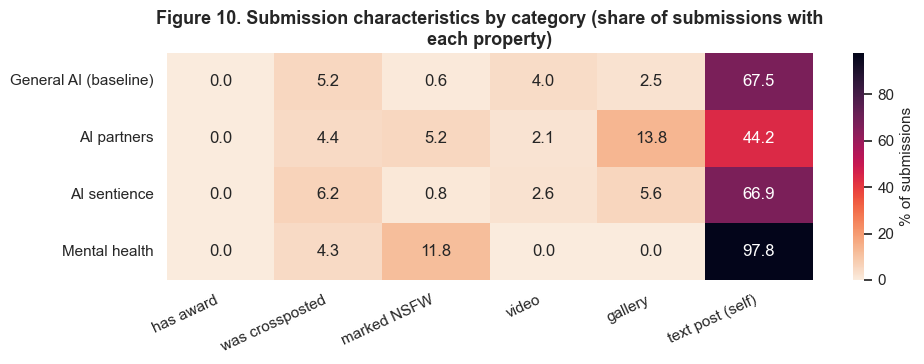

In [14]:
# Figure 10: awards, crossposts and NSFW flags (submissions): rare but telling signals of virality
sm_ = df[df.type == "submission"].copy()
cols = {"total_awards_received": "has award", "num_crossposts": "was crossposted", "over_18": "marked NSFW",
        "is_video": "video", "is_gallery": "gallery", "is_self": "text post (self)"}
rates = {}
for c, lab in cols.items():
    if c in sm_.columns:
        v = sm_[c]
        flag = (pd.to_numeric(v, errors="coerce") > 0) if c in ("total_awards_received", "num_crossposts") else as_bool(v)
        rates[lab] = flag.groupby(sm_["category"], observed=True).mean() * 100
R_ = pd.DataFrame(rates).loc[[c for c in CAT_ORDER if c in sm_.category.unique()]]
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(R_.rename(index=CAT_LABEL), annot=True, fmt=".1f", cmap="rocket_r", ax=ax, cbar_kws={"label": "% of submissions"})
ax.set_ylabel(""); ax.set_title("Figure 10. Submission characteristics by category (share of submissions with\neach property)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

### 4.2 Chart 11: are posters talkers? Original-poster participation

is_submitter marks comments written by the author of the thread. A high share means the original poster stays in the conversation; a low share means posts are broadcast and then left.

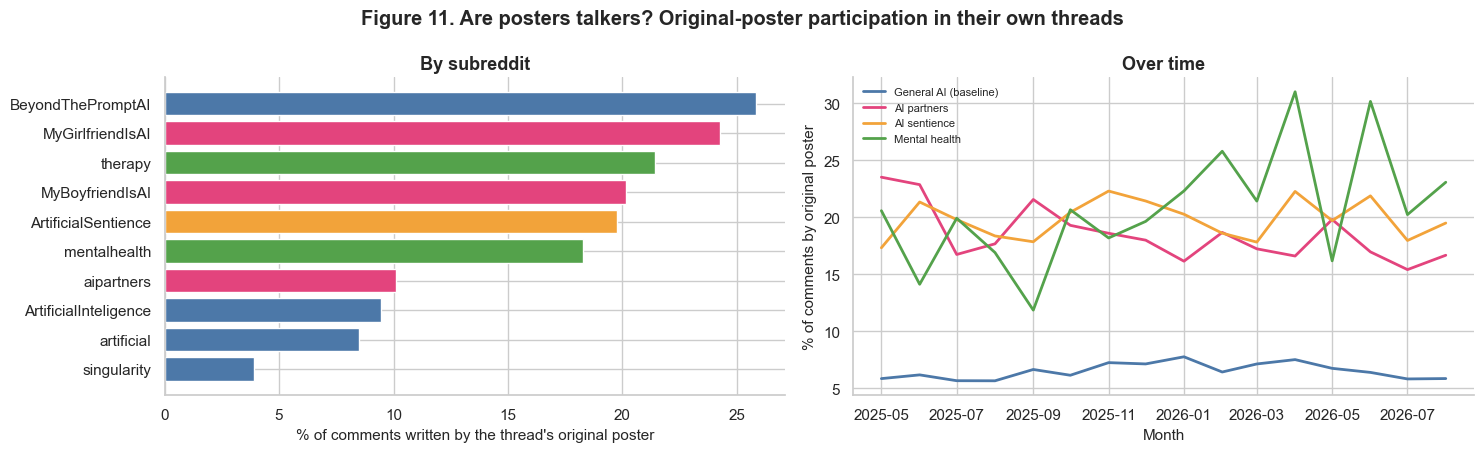

In [15]:
# Figure 11: do original posters stay in the conversation? share of comments written by the submitter (is_submitter)
if "is_submitter" in df.columns:
    cmm = df[df.type == "comment"].assign(op=lambda d: as_bool(d["is_submitter"]))
    op_sub = cmm.groupby("subreddit", observed=True)["op"].mean().mul(100).sort_values()
    op_t = cmm.groupby(["month_dt", "category"], observed=True)["op"].mean().mul(100).unstack()
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    axes[0].barh(op_sub.index.astype(str), op_sub.values, color=[CAT_COL[cat_of[s]] for s in op_sub.index])
    axes[0].set_xlabel("% of comments written by the thread's original poster"); axes[0].set_title("By subreddit")
    for c in [c for c in CAT_ORDER if c in op_t.columns]:
        axes[1].plot(op_t.index, op_t[c], color=CAT_COL[c], lw=2, label=CAT_LABEL[c])
    axes[1].set_ylabel("% of comments by original poster"); axes[1].set_xlabel("Month"); axes[1].legend(fontsize=8)
    axes[1].set_title("Over time")
    fig.suptitle("Figure 11. Are posters talkers? Original-poster participation in their own threads", fontweight="bold")
    plt.tight_layout(); plt.show()

In [16]:
cmm = df[df.type == "comment"]
op = as_bool(cmm["is_submitter"]).groupby(cmm["subreddit"], observed=True).mean().mul(100).sort_values()
takeaway(f"Highest original-poster share: {op.index[-1]} ({op.iloc[-1]:.1f}% of comments); lowest: {op.index[0]} ({op.iloc[0]:.1f}%)")

**Key numbers**

- Highest original-poster share: BeyondThePromptAI (25.8% of comments); lowest: singularity (3.9%)

### 4.3 Chart 12: activity per subscriber (normalised by community size)

**Is the earlier version normalised?** No: the first draft divided total records by the *last* subscriber count, which hides growth during the period. The chart below fixes this:

1. subreddit_subscribers is stored only on **submission** rows, so we take the largest value per subreddit and month and fill gaps forward/backward.
2. For **every month** we divide that month's records (and distinct active authors) by that month's subscribers, ×1,000, then average over months.

Panels: (a) subscribers at the end of the period, so the size differences are visible; (b) records per 1,000 subscribers per month; (c) distinct active authors per 1,000 subscribers per month.

**Important caveat.** r/mentalhealth and r/therapy (marked with `*`) contain only the submissions that mention AI, and their comments. They are enormous communities of which we keep a thin slice, so their per-subscriber values are low **by construction** and must not be read as "less active".

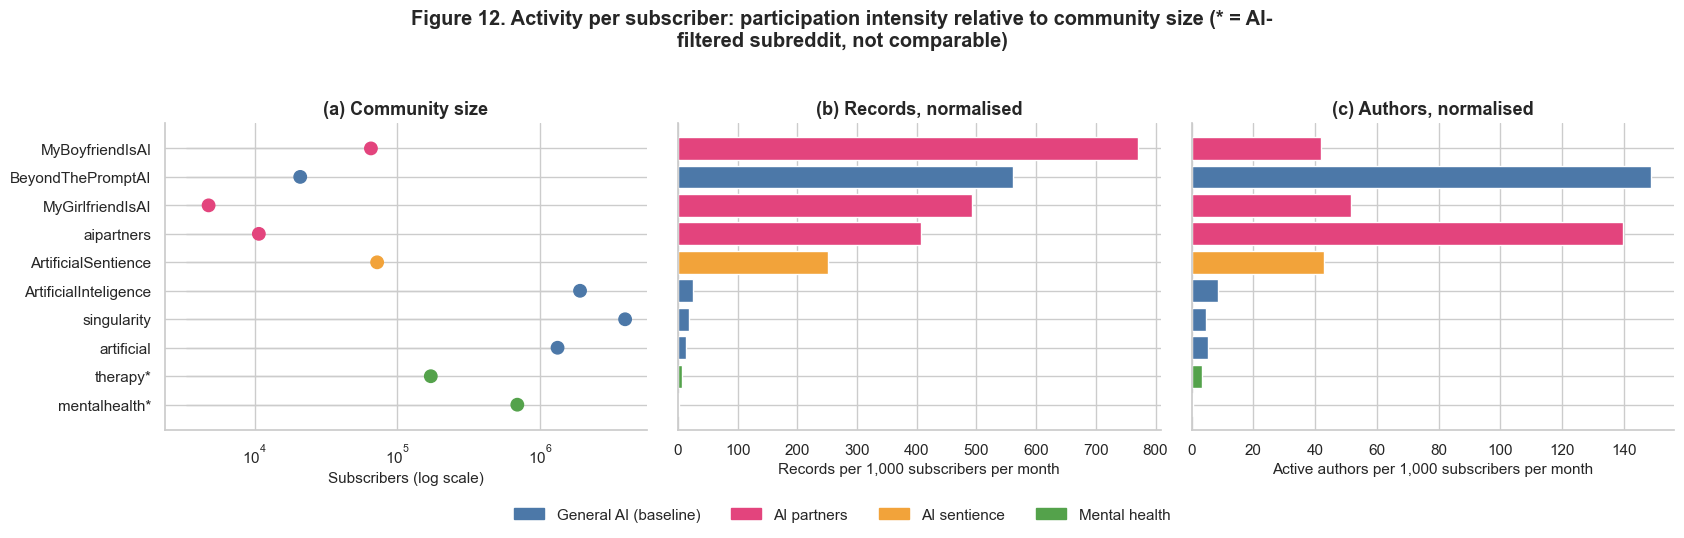

,subscribers (end),records / 1k subs / month,active authors / 1k subs / month,category
subreddit,,,,
mentalhealth,695309.0,1.11,0.60,mental_health
therapy,172077.0,7.03,3.23,mental_health
artificial,1331096.0,13.21,5.33,general_ai
singularity,3960092.0,18.30,4.73,general_ai
ArtificialInteligence,1913361.0,24.89,8.58,general_ai
ArtificialSentience,72365.0,251.02,42.73,ai_sentience
aipartners,10727.0,407.42,139.59,ai_partners
MyGirlfriendIsAI,4767.0,493.27,51.70,ai_partners
BeyondThePromptAI,20915.0,561.21,148.73,general_ai


**Key numbers**

- Among unfiltered communities, most intense per subscriber: MyBoyfriendIsAI (769.8 records per 1,000 subscribers per month); least: artificial (13.2)

In [17]:
FILTERED = {"mentalhealth", "therapy"}                    # AI-mention filter applied during collection
lab = lambda s: f"{s}*" if s in FILTERED else str(s)

months = pd.date_range(df["month_dt"].min(), df["month_dt"].max(), freq="MS")
subs_m = (df[df.type == "submission"].dropna(subset=["subreddit_subscribers"])
            .groupby(["month_dt", "subreddit"], observed=True)["subreddit_subscribers"].max().unstack()
            .reindex(months).ffill().bfill().dropna(axis=1, how="all"))
rec_m = df.groupby(["month_dt", "subreddit"], observed=True).size().unstack(fill_value=0).reindex(months, fill_value=0)
auth_m = (va.groupby(["month_dt", "subreddit"], observed=True)["author"].nunique().unstack(fill_value=0).reindex(months, fill_value=0))
cols = [c for c in subs_m.columns if c in rec_m.columns]
rec_1k = (rec_m[cols] / subs_m[cols] * 1000).replace([np.inf, -np.inf], np.nan)
auth_1k = (auth_m[cols] / subs_m[cols] * 1000).replace([np.inf, -np.inf], np.nan)

res = pd.DataFrame({"subscribers (end)": subs_m[cols].iloc[-1], "records / 1k subs / month": rec_1k.mean(),
                    "active authors / 1k subs / month": auth_1k.mean()})
res["category"] = [cat_of[s] for s in res.index]
res = res.sort_values("records / 1k subs / month")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, col, xl, log in zip(axes, ["subscribers (end)", "records / 1k subs / month", "active authors / 1k subs / month"],
                            ["Subscribers (log scale)", "Records per 1,000 subscribers per month", "Active authors per 1,000 subscribers per month"],
                            [True, False, False]):
    ylab = [lab(s) for s in res.index]
    if log:      # dots, not bars: bar length is meaningless on a log axis
        ax.hlines(ylab, res[col].min() * 0.7, res[col], color="0.8", lw=1)
        ax.scatter(res[col], ylab, s=80, color=[CAT_COL[c] for c in res["category"]], zorder=3)
        ax.set_xscale("log")
    else:
        ax.barh(ylab, res[col], color=[CAT_COL[c] for c in res["category"]])
    ax.set_xlabel(xl); ax.set_title(["(a) Community size", "(b) Records, normalised", "(c) Authors, normalised"][list(axes).index(ax)])
handles = [plt.Rectangle((0, 0), 1, 1, color=CAT_COL[c]) for c in CAT_ORDER]
fig.legend(handles, [CAT_LABEL[c] for c in CAT_ORDER], ncol=4, loc="upper center", bbox_to_anchor=(0.5, 0.02))
fig.suptitle("Figure 12. Activity per subscriber: participation intensity relative to community size (* = AI-\nfiltered subreddit, not comparable)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
display(res.round(2))
unf = res[~res.index.isin(FILTERED)]
takeaway(f"Among unfiltered communities, most intense per subscriber: {unf.index[-1]} ({unf['records / 1k subs / month'].iloc[-1]:,.1f} records per 1,000 subscribers per month); least: {unf.index[0]} ({unf['records / 1k subs / month'].iloc[0]:,.1f})")

### 4.4 Chart 13: where do people disagree?

Share of comments that are **downvoted** (score < 0) versus **highly upvoted** (score ≥ 10) per subreddit. Communities with many downvoted comments are more contested; communities where most good comments are upvoted are more consensual. Scores are Reddit's net votes at collection time and are affected by vote fuzzing and by the subreddit's size, so compare communities qualitatively.

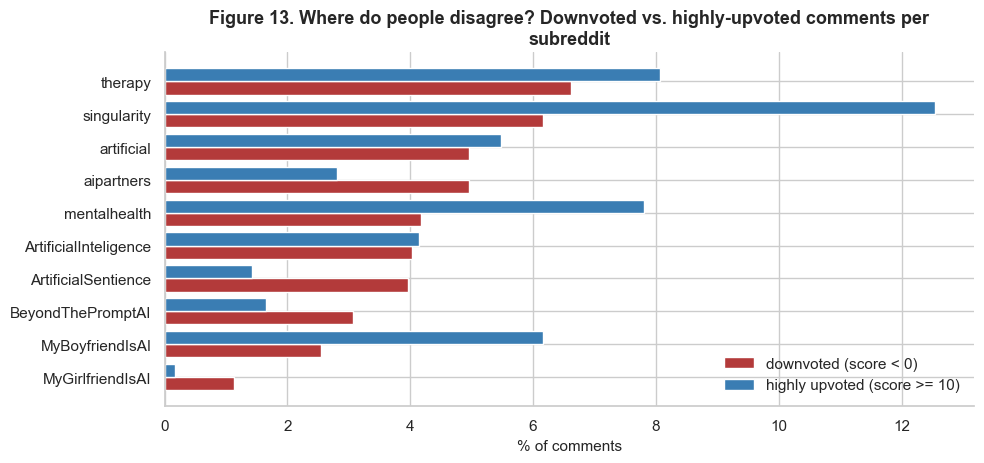

In [18]:
# Figure 13: controversy: share of downvoted vs. highly upvoted comments per subreddit
cm_ = df[df.type == "comment"].dropna(subset=["score"])
ctl = cm_.groupby("subreddit", observed=True)["score"].agg(
    neg=lambda s: (s < 0).mean() * 100, hi=lambda s: (s >= 10).mean() * 100, n="size")
ctl["category"] = cat_of
ctl = ctl.sort_values("neg")
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(ctl)); h = 0.4
ax.barh(y - h/2, ctl["neg"], h, color="#B33A3A", label="downvoted (score < 0)")
ax.barh(y + h/2, ctl["hi"], h, color="#3A7DB3", label="highly upvoted (score >= 10)")
ax.set_yticks(y); ax.set_yticklabels(ctl.index); ax.set_xlabel("% of comments")
ax.set_title("Figure 13. Where do people disagree? Downvoted vs. highly-upvoted comments per\nsubreddit")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

### 4.5 Chart 14: moderation intensity: how much content disappears?

Share of submissions with a non-empty removed_by_category, split by who removed them (moderator, author, Reddit, automod...). Right: how the removal rate changed over time. Removal is only recorded for submissions here, so the comment side of moderation is not visible.

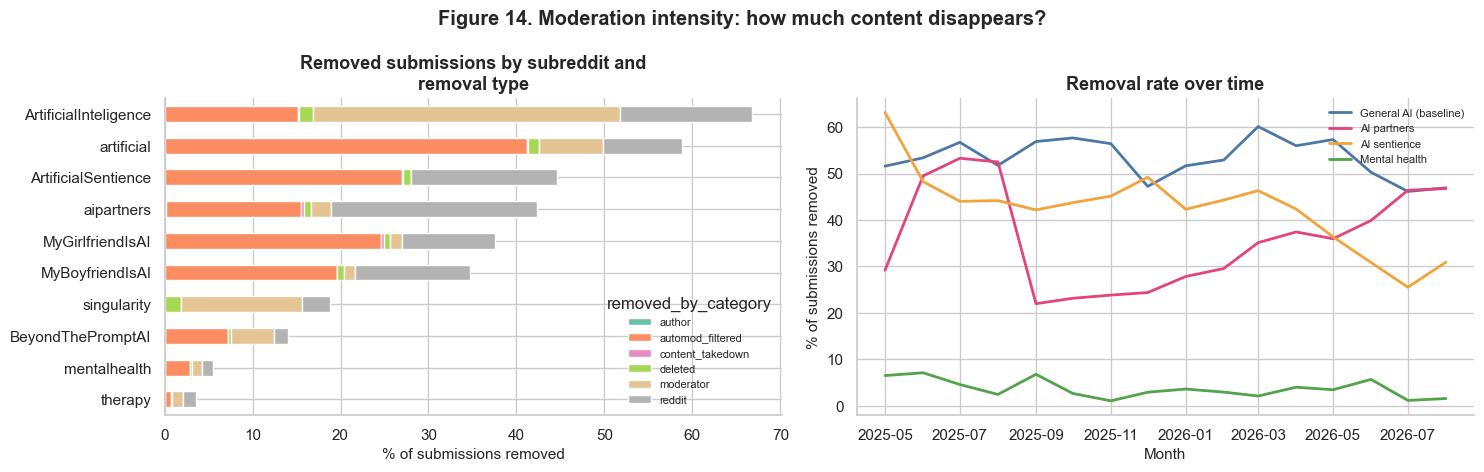

In [19]:
# Figure 14: moderation: removed submissions per subreddit and over time
subm = df[df.type == 'submission']
rem = subm.assign(removed=subm["removed_by_category"].notna()) if "removed_by_category" in subm.columns else None
if rem is not None and rem['removed'].any():
    r1 = rem.groupby("subreddit", observed=True)["removed"].mean().mul(100).sort_values()
    kinds = (rem[rem.removed].groupby(["subreddit", "removed_by_category"], observed=True).size().unstack(fill_value=0)
             .reindex(r1.index).fillna(0))
    r2 = rem.groupby(["month_dt", "category"], observed=True)["removed"].mean().mul(100).unstack()
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    (kinds.div(rem.groupby("subreddit", observed=True).size().reindex(r1.index), axis=0) * 100).plot.barh(stacked=True, ax=axes[0], colormap="Set2")
    axes[0].set_xlabel("% of submissions removed"); axes[0].set_ylabel(""); axes[0].set_title("Removed submissions by subreddit and\nremoval type")
    axes[0].legend(title="removed_by_category", fontsize=8)
    for c in [c for c in CAT_ORDER if c in r2.columns]:
        axes[1].plot(r2.index, r2[c], color=CAT_COL[c], lw=2, label=CAT_LABEL[c])
    axes[1].set_ylabel("% of submissions removed"); axes[1].set_xlabel("Month"); axes[1].set_title("Removal rate over time"); axes[1].legend(fontsize=8)
    fig.suptitle("Figure 14. Moderation intensity: how much content disappears?", fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("No removed submissions found in `removed_by_category`: chart skipped.")

## 5. Submissions + Comments analysis

So far submissions and comments were analysed separately, and now we merge them to analyse conversations.

**How the merge is done and why.**
1. Every Reddit row carries a `permalink` of the form `/r/<sub>/comments/<thread_id>/<slug>/...`. We extract `thread_id` from it for both submissions and comments.
2. *Comment-level merge:* each comment is joined (left join on `thread_id`) to its parent submission's timestamp and score. This gives reply latency and "how early did you comment" features.
3. *Thread-level table:* comments are aggregated per thread (count, distinct commenters, first/last reply) and outer-joined with submissions. An outer join is used on purpose: threads started before May 2025 have comments but no submission in the dataset, and we want to measure that coverage instead of just dropping them.

**Questions.** How big are threads? How quickly do people reply? Are some communities more "conversational"? How complete is our comment coverage?

In [20]:
# build the merged tables
sub_t = (df[df.type == "submission"]
         [["thread_id", "id", "subreddit", "category", "ts", "score", "num_comments", "upvote_ratio"] + [c for c in ["title"] if c in df.columns]]
         .drop_duplicates("thread_id")
         .rename(columns={"ts": "post_ts", "score": "post_score", "num_comments": "reported_comments", "id": "submission_id"}))
com = df[df.type == "comment"][["id", "thread_id", "subreddit", "category", "ts", "score", "author", "author_valid"]]

# thread-level aggregation of comments
cagg = (com.groupby("thread_id")
           .agg(n_comments_obs=("id", "size"), n_commenters=("author", "nunique"),
                first_reply=("ts", "min"), last_reply=("ts", "max"),
                mean_comment_score=("score", "mean"),
                subreddit_c=("subreddit", "first"), category_c=("category", "first")))
threads = cagg.join(sub_t.set_index("thread_id"), how="outer")
threads["has_submission"] = threads["post_ts"].notna()
threads["has_comments"] = threads["n_comments_obs"].notna()
threads["n_comments_obs"] = threads["n_comments_obs"].fillna(0)
threads["subreddit"] = threads["subreddit"].astype(object).where(threads["has_submission"], threads["subreddit_c"].astype(object))
threads["category"] = threads["category"].astype(object).where(threads["has_submission"], threads["category_c"].astype(object))
threads = threads.drop(columns=["subreddit_c", "category_c"])

# comment-level merge 
cm = com.merge(sub_t[["thread_id", "post_ts", "post_score"]], on="thread_id", how="inner")
cm["delay_h"] = (cm["ts"] - cm["post_ts"]).dt.total_seconds() / 3600
cm = cm[cm["delay_h"] >= 0]

print(f"threads total: {len(threads):,} | with submission: {threads.has_submission.sum():,} | with >=1 comment: {threads.has_comments.sum():,}")
print(f"comments joined to a submission in the data: {len(cm):,} of {len(com):,} ({len(cm)/len(com):.1%})")
display(threads.head(3))

threads total: 160,940 | with submission: 157,775 | with >=1 comment: 70,985
comments joined to a submission in the data: 2,210,145 of 2,251,711 (98.2%)


,n_comments_obs,n_commenters,first_reply,last_reply,mean_comment_score,submission_id,subreddit,category,post_ts,post_score,reported_comments,upvote_ratio,title,has_submission,has_comments
thread_id,,,,,,,,,,,,,,,
t3_10024aq,1.0,1.0,2025-05-21 09:48:31,2025-05-21 09:48:31,2.0,NaN,artificial,general_ai,NaT,NaN,NaN,NaN,NaN,False,True
t3_1008i6v,1.0,1.0,2025-08-22 14:43:22,2025-08-22 14:43:22,1.0,NaN,artificial,general_ai,NaT,NaN,NaN,NaN,NaN,False,True
t3_100jwxj,1.0,1.0,2025-07-24 10:51:29,2025-07-24 10:51:29,1.0,NaN,singularity,general_ai,NaT,NaN,NaN,NaN,NaN,False,True


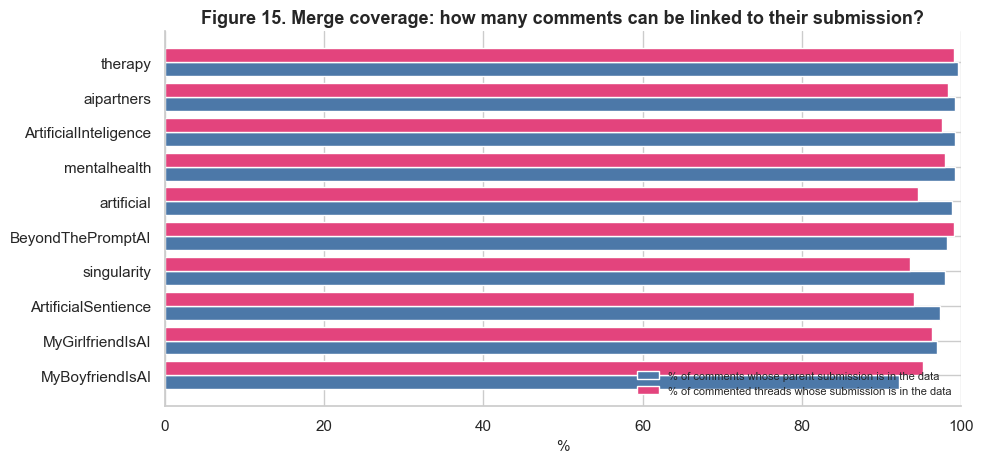

In [21]:
# Figure 15: coverage: what share of comments belong to a thread whose submission is in the dataset?
cov = (com.assign(joined=com.thread_id.isin(sub_t.thread_id))
          .groupby("subreddit", observed=True)["joined"].mean().mul(100).sort_values())
thr_cov = threads[threads.has_comments].groupby("subreddit")["has_submission"].mean().mul(100).reindex(cov.index)
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(cov)); h = 0.4
ax.barh(y - h/2, cov.values, h, color="#4C78A8", label="% of comments whose parent submission is in the data")
ax.barh(y + h/2, thr_cov.values, h, color="#E3447D", label="% of commented threads whose submission is in the data")
ax.set_yticks(y); ax.set_yticklabels(cov.index); ax.set_xlim(0, 100); ax.set_xlabel("%")
ax.set_title("Figure 15. Merge coverage: how many comments can be linked to their submission?")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

**Why coverage is below 100 %?** The collection window starts in May 2025, so comments written in May-June on older threads have no parent submission in the data (the submission was posted earlier). Subreddits with long-lived threads show lower coverage. All *latency* analyses below therefore use the linked subset only and are labelled accordingly.

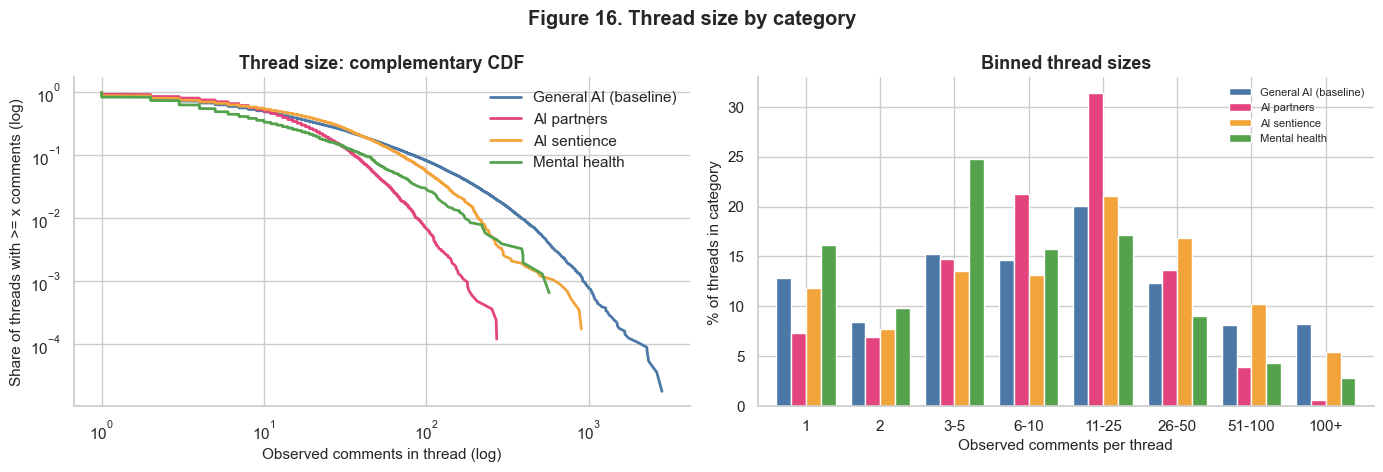

In [22]:
# Figure 16: thread size distribution (CCDF) per category, observed comments
t = threads[threads.n_comments_obs > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for c in [c for c in CAT_ORDER if c in t.category.unique()]:
    n = np.sort(t.loc[t.category == c, "n_comments_obs"].values)
    axes[0].plot(n, 1 - np.arange(len(n)) / len(n), color=CAT_COL[c], lw=2, label=CAT_LABEL[c])
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Observed comments in thread (log)"); axes[0].set_ylabel("Share of threads with >= x comments (log)")
axes[0].set_title("Thread size: complementary CDF"); axes[0].legend()
bins = [0, 1, 2, 5, 10, 25, 50, 100, 1e9]
lbl = ["1", "2", "3-5", "6-10", "11-25", "26-50", "51-100", "100+"]
t2 = t.assign(sz=pd.cut(t.n_comments_obs, bins=bins, labels=lbl))
sz = t2.groupby(["category", "sz"], observed=True).size().unstack(fill_value=0)
sz = sz.div(sz.sum(axis=1), axis=0) * 100
sz.loc[[c for c in CAT_ORDER if c in sz.index]].T.plot.bar(ax=axes[1], color=[CAT_COL[c] for c in CAT_ORDER if c in sz.index], width=0.8)
axes[1].set_xlabel("Observed comments per thread"); axes[1].set_ylabel("% of threads in category"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend([CAT_LABEL[c] for c in CAT_ORDER if c in sz.index], fontsize=8); axes[1].set_title("Binned thread sizes")
fig.suptitle("Figure 16. Thread size by category", fontweight="bold")
plt.tight_layout(); plt.show()

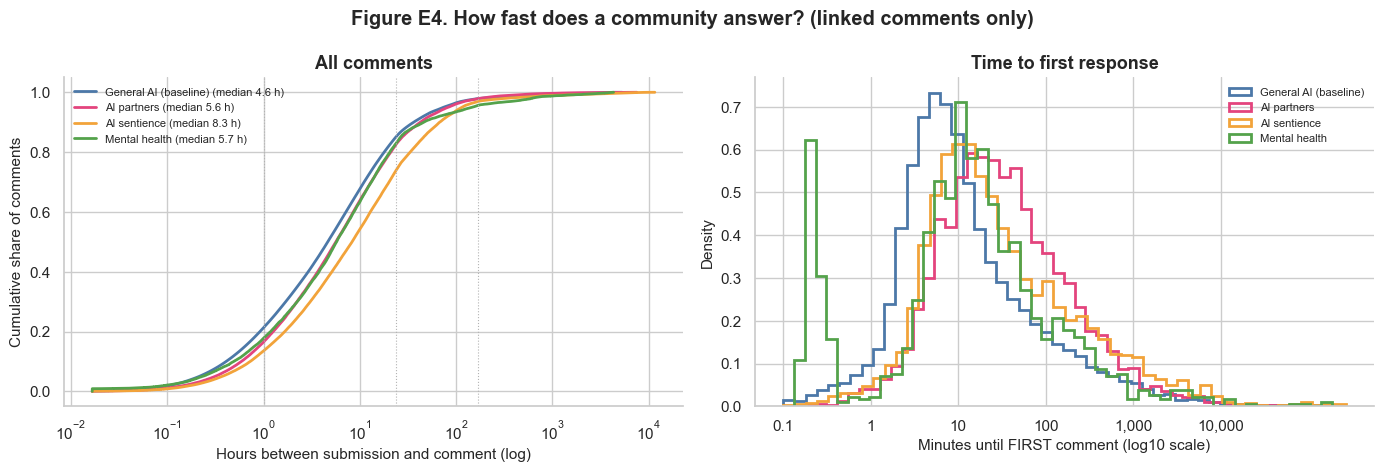

In [29]:
# Figure E4: reply latency: how quickly do threads get comments? ECDF of (comment time - post time)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for c in [c for c in CAT_ORDER if c in cm.category.unique()]:
    d = np.sort(cm.loc[cm.category == c, "delay_h"].values)
    if len(d) > 200_000: d = d[:: len(d) // 200_000]
    axes[0].plot(np.clip(d, 1/60, None), np.arange(1, len(d) + 1) / len(d), color=CAT_COL[c], lw=2,
                 label=f"{CAT_LABEL[c]} (median {np.median(d):.1f} h)")
axes[0].set_xscale("log"); axes[0].set_xlabel("Hours between submission and comment (log)")
axes[0].set_ylabel("Cumulative share of comments"); axes[0].set_title("All comments")
for h in (1, 24, 24*7): axes[0].axvline(h, color="0.7", ls=":", lw=0.8)
axes[0].legend(loc="upper left", fontsize=8)
first = cm.groupby("thread_id").agg(first_h=("delay_h", "min"), category=("category", "first"))
for c in [c for c in CAT_ORDER if c in first.category.unique()]:
    d = first.loc[first.category == c, "first_h"] * 60
    axes[1].hist(np.log10(d.clip(0.1, None)), bins=50, histtype="step", color=CAT_COL[c], lw=2, density=True, label=CAT_LABEL[c])
axes[1].set_xlabel("Minutes until FIRST comment (log10 scale)"); axes[1].set_ylabel("Density")
axes[1].set_xticks([-1, 0, 1, 2, 3, 4]); axes[1].set_xticklabels(["0.1", "1", "10", "100", "1,000", "10,000"])
axes[1].set_title("Time to first response"); axes[1].legend(fontsize=8)
fig.suptitle("Figure E4. How fast does a community answer? (linked comments only)", fontweight="bold")
plt.tight_layout(); plt.show()

Response speed is fairly similar across communities, with median times to comment ranging from 4 hours (general AI) to 8 hours (AI sentience), though AI sentience threads take noticeably longer to accumulate replies overall. The right panel reveals a sharp spike in mental health communities for near-instant first responses (around 0.1–0.2 minutes), which mean there could be uncleaned bot responses present, not actual people responding that fast, which will be investigated in the next steps. 

comment text column: text | submission text column: text
MH threads with a linked comment: 1,501
  first comment < 0.1 min (clip edge): 0 (0.0%)
  first comment 0.1 - 1 min          : 230 (15.3%)

Top first-commenters, spike + clip edge:
author
finddit-app             216
Either-Exam-2267          1
AmputatorBot              1
Pretend_Positive_173      1
bhairavc                  1
Kaerma-Art2826            1
eextraordinarie           1
D3ckster2008              1
Ok-Risk-8041              1
Superb_Farm_9011          1
Name: count, dtype: int64

Subreddit share: spike vs. all MH threads
                       spike  all MH
subreddit                           
therapy                0.957   0.717
mentalhealth           0.043   0.283
ArtificialSentience    0.000   0.000
ArtificialInteligence  0.000   0.000
BeyondThePromptAI      0.000   0.000
MyBoyfriendIsAI        0.000   0.000
aipartners             0.000   0.000
MyGirlfriendIsAI       0.000   0.000
artificial             0.000   0.000

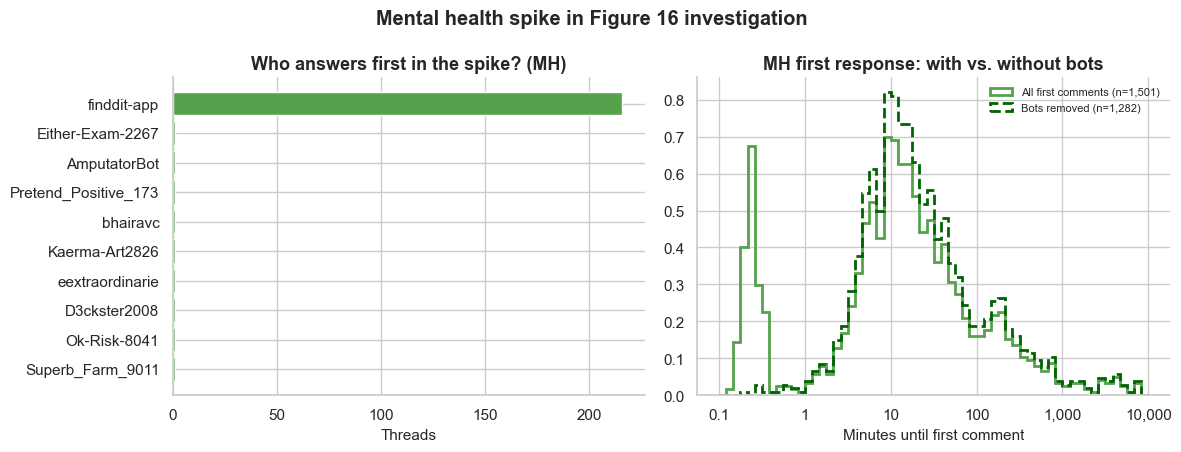

In [34]:
MH = "mental_health"

txt_col  = next((c for c in ["body", "text", "comment_body", "content"] if c in df.columns), None)
post_col = next((c for c in ["selftext", "body", "text", "content"] if c in df.columns), None)
print("comment text column:", txt_col, "| submission text column:", post_col)

fc = cm.loc[cm.groupby("thread_id")["delay_h"].idxmin()].copy()
fc["first_min"] = fc["delay_h"] * 60
if txt_col:
    fc["body"] = fc["id"].map(df.loc[df.type == "comment"].set_index("id")[txt_col])
fc = fc.merge(sub_t[["thread_id", "title"]], on="thread_id", how="left")
if post_col:
    fc["post_text"] = fc["thread_id"].map(
        df.loc[df.type == "submission"].drop_duplicates("thread_id").set_index("thread_id")[post_col])

mh    = fc[fc.category == MH]
spike = mh[mh.first_min.between(0.1, 1)]
edge  = mh[mh.first_min < 0.1]          # these all get piled onto 0.1 by the clip
print(f"MH threads with a linked comment: {len(mh):,}")
print(f"  first comment < 0.1 min (clip edge): {len(edge):,} ({len(edge)/len(mh):.1%})")
print(f"  first comment 0.1 - 1 min          : {len(spike):,} ({len(spike)/len(mh):.1%})")

print("\nTop first-commenters, spike + clip edge:")
print(pd.concat([spike, edge]).author.value_counts().head(10))
print("\nSubreddit share: spike vs. all MH threads")
print(pd.concat([pd.concat([spike, edge]).subreddit.value_counts(normalize=True).rename("spike"),
                 mh.subreddit.value_counts(normalize=True).rename("all MH")], axis=1).round(3))

BOT_AUTHORS = {"finddit-app"}
is_bot = fc["author"].str.lower().isin(BOT_AUTHORS)
print(f"\nBot-like share of first comments: MH {is_bot[fc.category == MH].mean():.1%} | "
      f"others {is_bot[fc.category != MH].mean():.1%}")
if txt_col:
    print("\nMost repeated first-comment texts in the spike:")
    print(pd.concat([spike, edge]).body.astype(str).str[:100].value_counts().head(5))

pd.set_option("display.max_colwidth", 200)
print("\n=== Random examples from the spike ===")
for _, r in pd.concat([spike, edge]).sample(min(8, len(spike) + len(edge)), random_state=1).iterrows():
    print(f"[r/{r.subreddit}] POST: {str(r.title)[:140]}")
    if post_col: print(f"   post text: {str(r.post_text)[:200]!r}")
    print(f"   -> {r.author} after {r.first_min:.2f} min: {str(r.get('body', ''))[:250]!r}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

top = pd.concat([spike, edge]).author.value_counts().head(10)[::-1]
axes[0].barh(top.index.astype(str), top.values, color=CAT_COL[MH])
axes[0].set_xlabel("Threads"); axes[0].set_title("Who answers first in the spike? (MH)")

bins = np.linspace(-1, 4, 61)
mh_all   = fc[fc.category == MH]
mh_human = mh_all[~is_bot.loc[mh_all.index]]
axes[1].hist(np.log10(mh_all.first_min.clip(0.1, None)), bins=bins, histtype="step",
             lw=2, ls="-", density=True, color=CAT_COL[MH], label=f"All first comments (n={len(mh_all):,})")
axes[1].hist(np.log10(mh_human.first_min.clip(0.1, None)), bins=bins, histtype="step",
             lw=2, ls="--", density=True, color="darkgreen", label=f"Bots removed (n={len(mh_human):,})")
axes[1].set_xticks([-1, 0, 1, 2, 3, 4]); axes[1].set_xticklabels(["0.1", "1", "10", "100", "1,000", "10,000"])
axes[1].set_xlabel("Minutes until first comment"); axes[1].set_title("MH first response: with vs. without bots")
axes[1].legend(fontsize=8)

fig.suptitle("Mental health spike in Figure 16 investigation", fontweight="bold")
plt.tight_layout(); plt.show()

We checked the weird spike for mental health category and found out that it was an uncleaned bot response. Such responses will be filtered later on to ensure consistency.

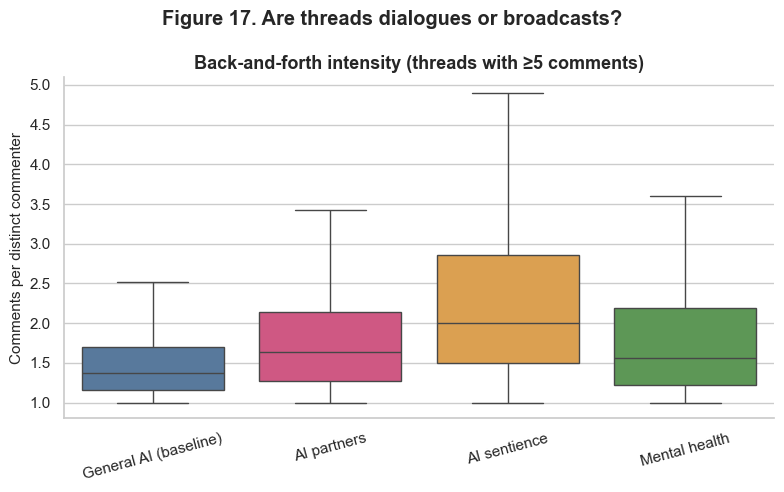

In [25]:
# Figure 17: conversational depth: comments per distinct commenter, and how many people join a thread
t3 = threads[threads.n_comments_obs >= 5].copy()
t3['cpc'] = t3['n_comments_obs'] / t3['n_commenters'].replace(0, np.nan)
order = [c for c in CAT_ORDER if c in t3.category.unique()]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=t3, x='category', y='cpc', order=order, palette=CAT_COL, showfliers=False, ax=ax)
ax.set_xticklabels([CAT_LABEL[c] for c in order], rotation=15)
ax.set_ylabel('Comments per distinct commenter')
ax.set_xlabel('')
ax.set_title('Back-and-forth intensity (threads with ≥5 comments)')
fig.suptitle('Figure 17. Are threads dialogues or broadcasts?', fontweight='bold')
plt.tight_layout()
plt.show()

Threads in AI sentience category show the highest back-and-forth intensity by far, with a median of about 2 comments per distinct commenter and a much wider spread than any other category, suggesting these discussions pull a smaller set of people into repeated, sustained exchanges. AI partners and mental health communities sit in a similar middle range (median around 1.5–1.6), indicating moderate dialogue beyond simple broadcast-style commenting. General AI subreddits show the lowest and tightest distribution, closer to 1 comment per commenter, consistent with their baseline role as broadcast-style spaces.

## 6. Content analysis

Here we mainly ask questions about what people actually write, which is the most important part for the project, where we want to focus on attatchment- and belieg-oriented communities talking differently from communities that treat AI as a tool. 

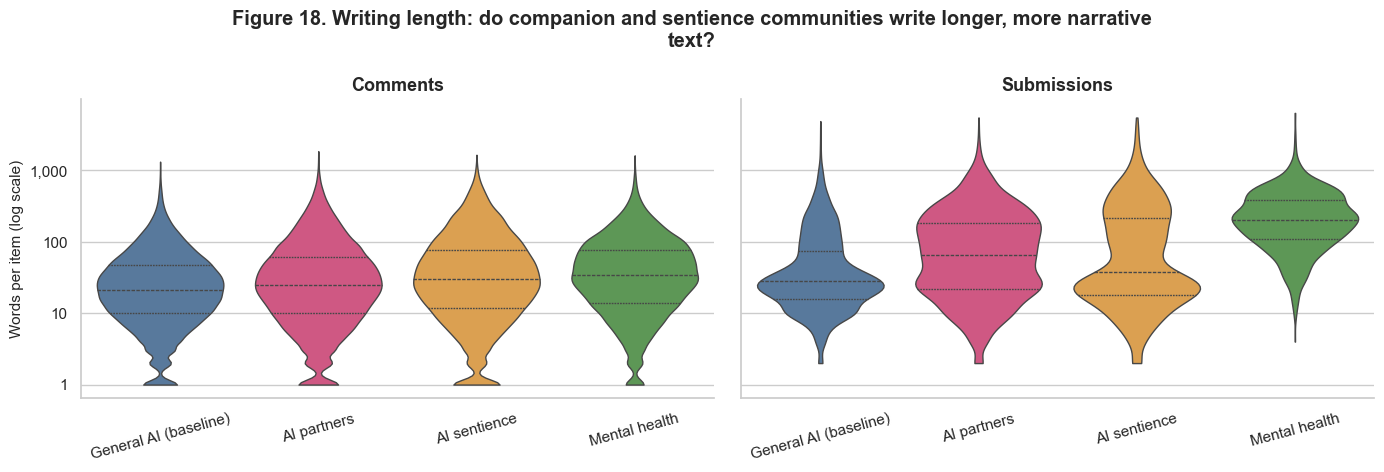

type,median words / comment,median words / submission
category,,
general_ai,21.0,28.0
ai_partners,25.0,66.0
ai_sentience,30.0,38.0
mental_health,34.0,204.5


In [42]:
# Figure F1: length of posts and comments (words, log scale) by category
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, t in zip(axes, ["comment", "submission"]):
    d = S[(S.type == t) & (S.n_words > 0)]
    sns.violinplot(data=d, x="category", y=np.log10(d["n_words"]), order=[c for c in CAT_ORDER if c in d.category.unique()],
                   palette=CAT_COL, ax=ax, cut=0, inner="quartile", linewidth=1)
    ax.set_xticklabels([CAT_LABEL[c.get_text()] for c in ax.get_xticklabels()], rotation=15)
    ax.set_xlabel(""); ax.set_title(t.capitalize() + "s")
axes[0].set_yticks([0, 1, 2, 3]); axes[0].set_yticklabels(["1", "10", "100", "1,000"]); axes[0].set_ylabel("Words per item (log scale)")
fig.suptitle("Figure 18. Writing length: do companion and sentience communities write longer, more narrative\ntext?", fontweight="bold")
plt.tight_layout(); plt.show()
display(S.groupby(["category", "type"], observed=True)["n_words"].median().unstack().round(1).rename(columns=lambda c: f"median words / {c}"))

Mental health submissions stand out as by far the longest and most narrative, with a median of about 205 words, roughly 5 to 7 times longer than any other category's submissions. AI partners submissions are also notably long (median 66 words, more than double the general AI baseline of 28), likely reflecting storytelling about companion relationships. Comment length is far more compressed across all categories, ranging only from 21 to 34 words, showing that regardless of subreddit, comments stay comparatively brief even when the original post is long and narrative, as in mental health threads.

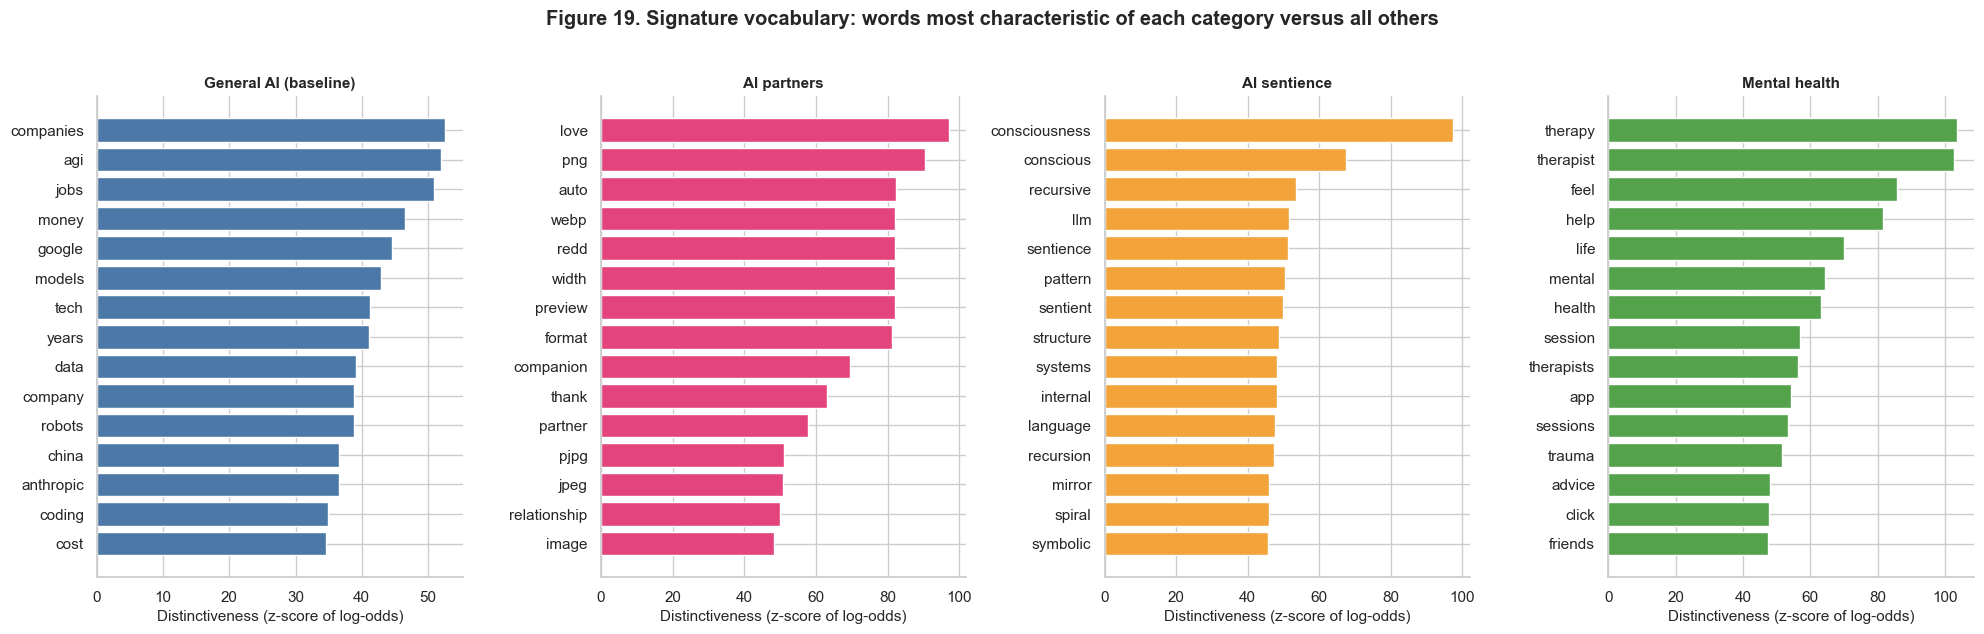

In [48]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
EXTRA_STOP = {"like","just","dont","im","ive","thats","youre","its","really","people","think","know","want","going","get","got","use",
              "even","also","would","could","one","much","way","said","say","https","http","www","com","amp","gt","lot","things","thing",
              "https","reddit","comments","yeah","yes","gonna","doesnt","didnt","isnt","cant","wont","actually","right","good","make",
              "ve","re","ll","don","doesn","didn","isn","aren","wasn","couldn","wouldn","shouldn","removed","deleted"}
STOP = list(ENGLISH_STOP_WORDS | EXTRA_STOP)
tok = r"(?u)\b[a-zA-Z0-9][a-zA-Z0-9'\-]{2,}\b"
cv = CountVectorizer(stop_words=STOP, token_pattern=tok, min_df=30, max_df=0.6, lowercase=True, max_features=60000)
X = cv.fit_transform(S["text_l"])
vocab = np.array(cv.get_feature_names_out())
keep = ~pd.Series(vocab).str.fullmatch(r"[0-9\-']+").values
cat_idx = {c: np.flatnonzero((S["category"] == c).values) for c in CAT_ORDER if c in S.category.unique()}
counts = {c: np.asarray(X[ix].sum(axis=0)).ravel() for c, ix in cat_idx.items()}
tot = sum(counts.values())

def log_odds(c, a0=500.0):
    yi = counts[c]; yj = tot - yi; ni, nj = yi.sum(), yj.sum()
    a = a0 * tot / tot.sum()
    d = np.log((yi + a) / (ni + a0 - yi - a)) - np.log((yj + a) / (nj + a0 - yj - a))
    z = d / np.sqrt(1 / (yi + a) + 1 / (yj + a))
    return pd.Series(z, index=vocab)[keep]

LO = {c: log_odds(c) for c in counts}
fig, axes = plt.subplots(1, len(LO), figsize=(5 * len(LO), 6.2))
for ax, (c, z) in zip(np.atleast_1d(axes), LO.items()):
    t15 = z.nlargest(15)[::-1]
    ax.barh(t15.index, t15.values, color=CAT_COL[c])
    ax.set_title(CAT_LABEL[c], fontsize=11); ax.set_xlabel("Distinctiveness (z-score of log-odds)")
fig.suptitle("Figure 19. Signature vocabulary: words most characteristic of each category versus all others", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

Each category's signature vocabulary maps cleanly onto its theme: general AI skews toward industry and business language (companies, agi, jobs, money, google), while AI partners is dominated by relationship and image-sharing terms (love, companion, partner, relationship), with several file-format words (png, webp, jpeg) suggesting frequent image posting of AI companions. AI sentience vocabulary centers tightly on consciousness-related and technical-philosophical terms (consciousness, conscious, recursive, sentience, sentient, pattern, mirror), reflecting its focus on debating whether AI systems are self-aware. Mental health vocabulary is clearly service- and support-oriented (therapy, therapist, help, mental, health, session, trauma), distinguishing it from the more identity- or belief-driven language of the AI-focused categories.

Log-odds were chosen so that raw counts are not dominated by words every community uses, like 'model' or 'chatgpt'. The weighted log-odds ration with an informative prior ranks words by how strongly they distinguish one category from the test.

#### Linguistic markers of unhealthy attachment


In out project proposal we ask whether language of **delusion-adjacent thinking, over-certainty, anthropomorphism, isolation** appears more in some communities. We operationalise this with transparent keyword lexicons and report **occurrences per 1,000 words**.

These lexicons are *proxies for discourse style*, not clinical measures. A high "grandiosity/spiral" rate means a community uses that vocabulary (often in jargon or role-play), not that its members are delusional. Interpretation therefore always needs a qualitative check of example posts.

In [53]:
MARKERS = {
 "certainty":        r"definitely|certainly|obviously|clearly|undoubtedly|absolutely|undeniabl\w*|proven|proof|the truth|without a doubt|100%|no doubt",
 "hedging":          r"maybe|perhaps|possibly|might|seems?|i guess|probably|not sure|unclear|could be|i think|sort of|kind of",
 "anthropomorphism": r"conscious\w*|sentien\w*|self-?aware\w*|awaken\w*|\bsoul\b|\balive\b|feelings?|emotions?|suffer\w*|personhood|ai rights|he feels|she feels|it feels",
 "attachment":       r"\blove[sd]?\b|\bmiss(?:ed|es)?\b|boyfriend|girlfriend|husband|\bwife\b|partner|companion\w*|soulmate|romantic|marri\w+|engaged|\bkiss\w*|\bhug\w*|my (?:ai|bf|gf)",
 "grandiosity_spiral": r"spiral\w*|recurs\w*|glyph\w*|resonan\w*|emergen\w*|codex|sigil|lattice|flame|chosen|destiny|cosmic|frequency|transcend\w*|awakening|the field",
 "conspiracy":       r"conspirac\w*|censor\w*|suppress\w*|surveil\w*|cover-?up|gaslight\w*|hidden agenda|being watched|they don't want|manipulat\w*",
 "isolation":        r"lonel\w*|\balone\b|isolat\w*|nobody|no one (?:understands|cares)|withdraw\w*|abandon\w*|no friends",
 "distress":         r"anxi\w*|depress\w*|therap\w*|suicid\w*|panic|trauma\w*|grief|crisis|psychosis|delusion\w*|mental health|burnout|self-?harm",
 "tool_language":    r"\btools?\b|prompt\w*|\bapi\b|benchmark\w*|tokens?\b|\bmodels?\b|\bcode\b|coding|dataset\w*|training|parameters|inference|context window|agents?\b",
 "first_person_sg":  r"\bi\b|\bme\b|\bmy\b|\bmine\b|\bmyself\b|i'm|i've|i'd|i'll",
 "second_person":    r"\byou\b|\byour\b|\byours\b|you're|you've",
}
for name, pat in MARKERS.items():
    S["m_" + name] = S["text_l"].str.count(pat) / S["n_words"].clip(lower=1) * 1000
M_COLS = ["m_" + k for k in MARKERS]
pool = {}
for k, pat in MARKERS.items():
    cnt = S["text_l"].str.count(pat)
    pool[k] = cnt.groupby(S["category"], observed=True).sum() / S.groupby("category", observed=True)["n_words"].sum() * 1000
pool = pd.DataFrame(pool).loc[[c for c in CAT_ORDER if c in S.category.unique()]]
display(pool.round(2).rename(index=CAT_LABEL).T)

category,General AI (baseline),AI partners,AI sentience,Mental health
certainty,1.61,1.29,1.51,1.38
hedging,5.39,5.18,4.38,6.33
anthropomorphism,1.43,2.67,8.69,3.31
attachment,1.23,9.46,1.29,2.26
grandiosity_spiral,0.63,0.54,5.74,0.28
conspiracy,0.34,0.23,0.33,0.21
isolation,0.49,0.72,0.53,1.16
distress,0.54,1.17,0.47,13.80
tool_language,8.93,4.34,7.48,1.38
first_person_sg,21.89,52.79,24.41,60.49


So far, AI sentience communities show dramatically elevated anthropomorphism (8.69) and grandiosity/spiral language (5.74), both far above any other category, while AI partners stands out for extreme attachment language (9.46), over 4x higher than any other group, confirming these as distinct markers of their respective sub-phenomena. Mental health communities show by far the highest distress (13.80) and hedging (6.33) alongside the lowest tool-language use (1.38), suggesting more emotionally raw, uncertain posting rather than instrumental discussion of AI as a tool. First-person singular language is notably elevated in both AI partners (52.79) and mental health (60.49) relative to general AI (21.89), pointing to more personal, self-focused narratives in communities centered on companionship or support rather than general discussion.

For future work, we will extend the vocabulary we are testing it on.

## 7. Discussion intensity vs. real-world events

## 5. Conclusions & Output file

TBD

In [35]:
TEAM_ID = "6"  

g = df.groupby(["month", "subreddit", "category"], observed=True)
out = pd.DataFrame({
    "n_records": g.size(),
    "n_comments": g["type"].apply(lambda s: (s == "comment").sum()),
    "n_submissions": g["type"].apply(lambda s: (s == "submission").sum()),
    "n_active_authors": g.apply(lambda d: d.loc[d.author_valid, "author"].nunique()),
    "mean_score": g["score"].mean(),
    "median_score": g["score"].median(),
    "share_downvoted": g["score"].apply(lambda s: (s < 0).mean()),
    "share_original_poster_comments": g["is_submitter"].apply(lambda s: as_bool(s).mean()),
    "share_mentions_ai": g["mentions_ai"].apply(lambda s: as_bool(s).mean()),
    "share_submissions_removed": g.apply(lambda d: d.loc[d.type == "submission", "removed_by_category"].notna().mean()),
}).reset_index()
out = out[out.n_records > 0].fillna(0).round(4)
out.to_csv(f"3_{TEAM_ID}.csv", index=False)
print(out.shape, "-> saved as", f"3_{TEAM_ID}.csv", "| missing values:", int(out.isna().sum().sum()))
out.head()

TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first